# Clase 2 — TF-IDF y similitud

**Módulo de Análisis de Datos de Texto · Notebook 2 de 5**

En la clase anterior convertimos texto en una matriz de frecuencias. Hoy:

1. Pesar los términos con **TF-IDF**.
2. Identificar las *palabras características* de cada documento.
3. Representar documentos como vectores y compararlos con **similitud coseno**.
4. Construir un buscador minúsculo y detectar casi-duplicados.

## 1. Cargar el corpus

In [1]:
# Corpus de noticias en español (40 documentos cortos, 4 temas).
# Está embebido aquí para que el notebook sea autocontenido.

CORPUS = [
    # --- tecnología ---
    "Una empresa de tecnología presentó un nuevo modelo de inteligencia artificial capaz de generar texto en varios idiomas.",
    "El nuevo procesador promete duplicar la velocidad de los computadores portátiles sin aumentar el consumo de energía.",
    "Los algoritmos de aprendizaje automático están transformando la forma en que las empresas analizan datos masivos.",
    "Un grupo de investigadores publicó un modelo de lenguaje entrenado con miles de millones de palabras en español.",
    "La compañía lanzó una actualización de software que mejora la seguridad y corrige varios errores críticos.",
    "Expertos en ciberseguridad advierten sobre el aumento de ataques con inteligencia artificial generativa.",
    "El nuevo teléfono incorpora una cámara con procesamiento neuronal y reconocimiento de escenas en tiempo real.",
    "Los chips fabricados con tecnología de tres nanómetros llegarán al mercado el próximo año.",
    "Una startup colombiana desarrolló una aplicación que usa modelos de lenguaje para asesoría legal automatizada.",
    "El centro de datos consume menos energía gracias a un sistema de refrigeración basado en agua reciclada.",
    # --- deportes ---
    "El equipo nacional ganó el partido por tres goles a uno en el estadio principal de la capital.",
    "La selección de fútbol clasificó al mundial tras vencer a su rival histórico en tiempo de descuento.",
    "El ciclista colombiano subió al podio en la última etapa de la competencia europea.",
    "Un nuevo récord mundial fue establecido en los cien metros planos durante el campeonato.",
    "El entrenador anunció cambios en la alineación titular para el próximo partido decisivo.",
    "La final del torneo de baloncesto se jugará el sábado entre los dos mejores equipos del país.",
    "El tenista venció en cinco sets a su rival y avanzó a la final del torneo de Grand Slam.",
    "La atleta rompió la marca regional en lanzamiento de jabalina durante los juegos panamericanos.",
    "El nadador colombiano se clasificó a los juegos olímpicos tras una temporada excepcional.",
    "El partido fue suspendido por lluvia y se reanudará mañana en el mismo estadio.",
    # --- política ---
    "El gobierno anunció una nueva reforma tributaria que afectará a las grandes empresas del país.",
    "El congreso aprobó la ley de presupuesto general tras tres jornadas de intenso debate.",
    "La oposición criticó las medidas económicas anunciadas por el ministerio de hacienda esta semana.",
    "El presidente recibió a los líderes regionales para discutir la situación de seguridad en el sur del país.",
    "Las elecciones regionales se celebrarán en octubre con más de cuarenta millones de votantes habilitados.",
    "La corte constitucional declaró inexequible un artículo clave de la última reforma laboral aprobada.",
    "El alcalde presentó el plan de desarrollo con énfasis en movilidad y educación pública.",
    "Un acuerdo de paz entre las facciones políticas permitirá retomar el diálogo sobre la reforma rural.",
    "La ministra de educación defendió ante el congreso el aumento del presupuesto para universidades públicas.",
    "Los partidos políticos comenzaron las negociaciones para definir candidatos a la próxima campaña presidencial.",
    # --- cultura ---
    "La nueva película del director colombiano fue seleccionada para competir en el festival de cine de Cannes.",
    "El museo nacional inauguró una exposición sobre arte precolombino con piezas inéditas del periodo muisca.",
    "Un libro de poesía colombiana ganó el premio internacional de literatura en lengua española este año.",
    "La banda anunció gira mundial con conciertos en quince ciudades de América Latina y Europa.",
    "El festival de cine independiente proyectará más de cien películas durante dos semanas en la capital.",
    "La orquesta sinfónica estrenó una obra del compositor antioqueño con gran acogida del público.",
    "El teatro municipal presenta esta semana una adaptación contemporánea de una obra clásica del siglo de oro.",
    "Una escritora joven publicó su primera novela y ya ha sido traducida a cinco idiomas.",
    "El documental sobre música tradicional del pacífico colombiano fue estrenado en una plataforma de streaming.",
    "La feria del libro recibió más de medio millón de visitantes y cerró con un balance positivo.",
]

LABELS = (
    ["tecnología"] * 10
    + ["deportes"] * 10
    + ["política"] * 10
    + ["cultura"] * 10
)

print(f'Corpus: {len(CORPUS)} documentos en {len(set(LABELS))} categorías.')

Corpus: 40 documentos en 4 categorías.


In [2]:
CORPUS_TANGO = [
    "El tango es un baile popular",
    "Escuchar tango es placentero",
    "Gardel es un gran valor del tango",
    "Con el tango líquido los sueldos",
    "El tango 01 fue vendido",
]

import nltk
nltk.download("stopwords", quiet=True)
from nltk.corpus import stopwords
SW = sorted(stopwords.words("spanish"))

## 2. TF-IDF a mano sobre el corpus de juguete

Vamos a calcular TF-IDF *paso a paso* sobre las 5 frases del tango, para verificar la fórmula que vimos en las slides:

$$\text{tfidf}(t, d) = \text{tf}(t, d) \times \log\!\left(\frac{N}{\text{df}(t)}\right)$$

In [3]:
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

vec = CountVectorizer(stop_words=SW, lowercase=True)
X = vec.fit_transform(CORPUS_TANGO).toarray()
terms = vec.get_feature_names_out()
N = X.shape[0]   # número de documentos

# Document frequency: en cuántos documentos aparece cada término
df = (X > 0).sum(axis=0)
idf = np.log(N / df)

print("Término         df    idf")
print("-" * 32)
for t, d, i in zip(terms, df, idf):
    print(f"  {t:13s}  {d}    {i:.3f}")

Término         df    idf
--------------------------------
  01             1    1.609
  baile          1    1.609
  escuchar       1    1.609
  gardel         1    1.609
  gran           1    1.609
  líquido        1    1.609
  placentero     1    1.609
  popular        1    1.609
  sueldos        1    1.609
  tango          5    0.000
  valor          1    1.609
  vendido        1    1.609


**Lectura.** `"tango"` aparece en los 5 documentos (df=5), entonces idf = log(5/5) = 0. Su peso TF-IDF será **cero** en cualquier documento, aunque sea el tema central — porque no sirve para distinguir un documento de otro. Términos como `"gardel"` o `"sueldos"` aparecen en 1 solo documento (df=1), idf alto, peso alto: caracterizan a su texto.

In [4]:
# TF-IDF a mano = TF × IDF (TF aquí es el conteo crudo)
tfidf_manual = X * idf

df_tfidf = pd.DataFrame(tfidf_manual.round(3), columns=terms,
                        index=[f"D{i+1}" for i in range(N)])
df_tfidf

,01,baile,escuchar,gardel,gran,líquido,placentero,popular,sueldos,tango,valor,vendido
D1,0.000,1.609,0.000,0.000,0.000,0.000,0.000,1.609,0.000,0.0,0.000,0.000
D2,0.000,0.000,1.609,0.000,0.000,0.000,1.609,0.000,0.000,0.0,0.000,0.000
D3,0.000,0.000,0.000,1.609,1.609,0.000,0.000,0.000,0.000,0.0,1.609,0.000
D4,0.000,0.000,0.000,0.000,0.000,1.609,0.000,0.000,1.609,0.0,0.000,0.000
D5,1.609,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.0,0.000,1.609


### Comparación con `TfidfVectorizer`

scikit-learn aplica un par de normalizaciones (`smooth_idf` y normalización L2 por fila) que dan valores ligeramente distintos, pero el ranking de términos por documento es el mismo.

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfv = TfidfVectorizer(stop_words=SW, lowercase=True)
Xt = tfv.fit_transform(CORPUS_TANGO).toarray()
df_sk = pd.DataFrame(Xt.round(3), columns=tfv.get_feature_names_out(),
                     index=[f"D{i+1}" for i in range(N)])
df_sk

,01,baile,escuchar,gardel,gran,líquido,placentero,popular,sueldos,tango,valor,vendido
D1,0.00,0.67,0.00,0.000,0.000,0.00,0.00,0.67,0.00,0.319,0.000,0.00
D2,0.00,0.00,0.67,0.000,0.000,0.00,0.67,0.00,0.00,0.319,0.000,0.00
D3,0.00,0.00,0.00,0.557,0.557,0.00,0.00,0.00,0.00,0.265,0.557,0.00
D4,0.00,0.00,0.00,0.000,0.000,0.67,0.00,0.00,0.67,0.319,0.000,0.00
D5,0.67,0.00,0.00,0.000,0.000,0.00,0.00,0.00,0.00,0.319,0.000,0.67


## 3. TF-IDF sobre el corpus de noticias

In [6]:
tfv_n = TfidfVectorizer(stop_words=SW, lowercase=True, min_df=2)
Xn = tfv_n.fit_transform(CORPUS)
terms_n = tfv_n.get_feature_names_out()
print(f"Matriz TF-IDF de noticias: {Xn.shape}")

Matriz TF-IDF de noticias: (40, 52)


In [7]:
# Palabras CARACTERÍSTICAS de cada documento (top-3 por peso TF-IDF)
import numpy as np

def top_terminos(doc_idx, k=3):
    fila = Xn[doc_idx].toarray().ravel()
    top = np.argsort(-fila)[:k]
    return [(terms_n[j], round(fila[j], 3)) for j in top]

print("Palabras características por documento (primeros 8 documentos):\n")
for i in range(8):
    print(f"  D{i:02d} [{LABELS[i]:11s}]: {top_terminos(i)}")
    print(f"        “{CORPUS[i][:75]}...”\n")

Palabras características por documento (primeros 8 documentos):

  D00 [tecnología ]: [('artificial', np.float64(0.36)), ('modelo', np.float64(0.36)), ('idiomas', np.float64(0.36))]
        “Una empresa de tecnología presentó un nuevo modelo de inteligencia artifici...”

  D01 [tecnología ]: [('energía', np.float64(0.759)), ('nuevo', np.float64(0.651)), ('anunció', np.float64(0.0))]
        “El nuevo procesador promete duplicar la velocidad de los computadores portá...”

  D02 [tecnología ]: [('datos', np.float64(0.707)), ('empresas', np.float64(0.707)), ('anunció', np.float64(0.0))]
        “Los algoritmos de aprendizaje automático están transformando la forma en qu...”

  D03 [tecnología ]: [('modelo', np.float64(0.5)), ('lenguaje', np.float64(0.5)), ('millones', np.float64(0.5))]
        “Un grupo de investigadores publicó un modelo de lenguaje entrenado con mile...”

  D04 [tecnología ]: [('varios', np.float64(0.707)), ('seguridad', np.float64(0.707)), ('anunció', np.float64(0.0))]

## 4. Similitud coseno

Cada documento es un vector. Para comparar dos documentos medimos el **ángulo** entre sus vectores (la magnitud, que depende del largo del texto, se ignora).

$$\text{sim}(A, B) = \cos(\theta) = \frac{A \cdot B}{\|A\| \, \|B\|}$$

In [8]:
from sklearn.metrics.pairwise import cosine_similarity

S = cosine_similarity(Xn)   # matriz |D| x |D|
print(f"Matriz de similitud: {S.shape}")
print(f"Similitud de un documento consigo mismo (debe ser 1.0): {S[0,0]:.3f}")
print(f"Similitud entre D0 (tecno) y D10 (deportes):           {S[0,10]:.3f}")
print(f"Similitud entre D0 (tecno) y D5  (tecno):              {S[0,5]:.3f}")

Matriz de similitud: (40, 40)
Similitud de un documento consigo mismo (debe ser 1.0): 1.000
Similitud entre D0 (tecno) y D10 (deportes):           0.000
Similitud entre D0 (tecno) y D5  (tecno):              0.415


### Heatmap: ¿se ven los temas?

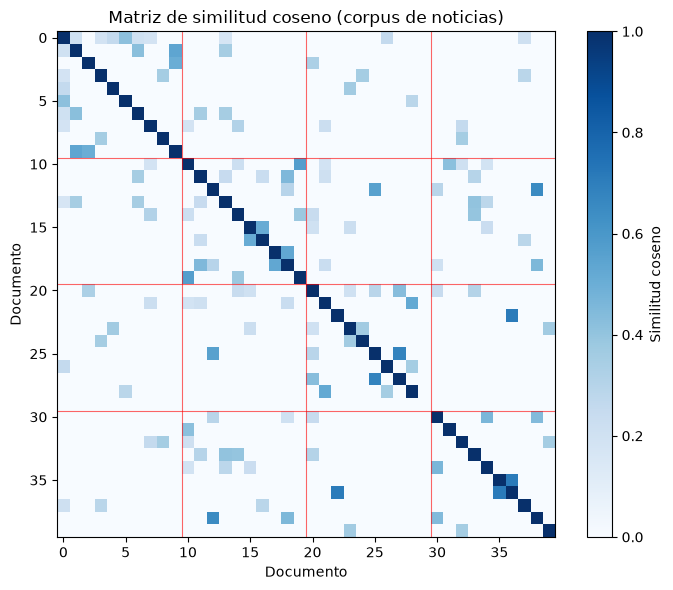

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(S, cmap="Blues", aspect="auto")
plt.colorbar(im, ax=ax, label="Similitud coseno")

# Marcamos las fronteras entre temas
for k in [10, 20, 30]:
    ax.axhline(k - 0.5, color="red", linewidth=0.8, alpha=0.6)
    ax.axvline(k - 0.5, color="red", linewidth=0.8, alpha=0.6)

ax.set_title("Matriz de similitud coseno (corpus de noticias)")
ax.set_xlabel("Documento"); ax.set_ylabel("Documento")
plt.tight_layout(); plt.show()

Deberías ver **bloques** brillantes en la diagonal: los documentos dentro de un mismo tema se parecen más entre sí que con documentos de otros temas. Los temas emergen sin que se los hayamos dicho al modelo.

## 5. Un buscador minúsculo

Una consulta es un texto cualquiera; la convertimos al mismo espacio TF-IDF y rankeamos los documentos por similitud coseno.

In [10]:
def buscar(consulta, k=3):
    q = tfv_n.transform([consulta])         # vector TF-IDF de la consulta
    sims = cosine_similarity(q, Xn).ravel()
    top = np.argsort(-sims)[:k]
    print(f"Consulta: «{consulta}»\n")
    for rank, i in enumerate(top, 1):
        print(f"  {rank}. [sim={sims[i]:.3f}] [{LABELS[i]}]")
        print(f"     {CORPUS[i]}\n")

buscar("inteligencia artificial y modelos de lenguaje")

Consulta: «inteligencia artificial y modelos de lenguaje»

  1. [sim=0.667] [tecnología]
     Expertos en ciberseguridad advierten sobre el aumento de ataques con inteligencia artificial generativa.

  2. [sim=0.415] [tecnología]
     Una empresa de tecnología presentó un nuevo modelo de inteligencia artificial capaz de generar texto en varios idiomas.

  3. [sim=0.408] [tecnología]
     Una startup colombiana desarrolló una aplicación que usa modelos de lenguaje para asesoría legal automatizada.



In [11]:
buscar("final del torneo de fútbol")

Consulta: «final del torneo de fútbol»

  1. [sim=0.721] [deportes]
     La final del torneo de baloncesto se jugará el sábado entre los dos mejores equipos del país.

  2. [sim=0.707] [deportes]
     El tenista venció en cinco sets a su rival y avanzó a la final del torneo de Grand Slam.

  3. [sim=0.000] [tecnología]
     Los algoritmos de aprendizaje automático están transformando la forma en que las empresas analizan datos masivos.



In [12]:
buscar("reforma del gobierno y presupuesto")

Consulta: «reforma del gobierno y presupuesto»

  1. [sim=0.677] [política]
     Un acuerdo de paz entre las facciones políticas permitirá retomar el diálogo sobre la reforma rural.

  2. [sim=0.459] [política]
     La corte constitucional declaró inexequible un artículo clave de la última reforma laboral aprobada.

  3. [sim=0.383] [política]
     El congreso aprobó la ley de presupuesto general tras tres jornadas de intenso debate.



## 6. Detección de casi-duplicados

In [13]:
# Pares de documentos con similitud > umbral (sin contar la diagonal)
UMBRAL = 0.25

pares = []
for i in range(len(CORPUS)):
    for j in range(i+1, len(CORPUS)):
        if S[i, j] > UMBRAL:
            pares.append((S[i, j], i, j))
pares.sort(reverse=True)

print(f"Pares con similitud > {UMBRAL}:  {len(pares)}\n")
for sim, i, j in pares[:5]:
    print(f"  sim={sim:.3f}  D{i:02d}[{LABELS[i]}]  ~  D{j:02d}[{LABELS[j]}]")
    print(f"    D{i:02d}: {CORPUS[i][:70]}...")
    print(f"    D{j:02d}: {CORPUS[j][:70]}...\n")

Pares con similitud > 0.25:  47

  sim=0.707  D35[cultura]  ~  D36[cultura]
    D35: La orquesta sinfónica estrenó una obra del compositor antioqueño con g...
    D36: El teatro municipal presenta esta semana una adaptación contemporánea ...

  sim=0.707  D22[política]  ~  D36[cultura]
    D22: La oposición criticó las medidas económicas anunciadas por el minister...
    D36: El teatro municipal presenta esta semana una adaptación contemporánea ...

  sim=0.677  D25[política]  ~  D27[política]
    D25: La corte constitucional declaró inexequible un artículo clave de la úl...
    D27: Un acuerdo de paz entre las facciones políticas permitirá retomar el d...

  sim=0.651  D12[deportes]  ~  D38[cultura]
    D12: El ciclista colombiano subió al podio en la última etapa de la compete...
    D38: El documental sobre música tradicional del pacífico colombiano fue est...

  sim=0.570  D10[deportes]  ~  D19[deportes]
    D10: El equipo nacional ganó el partido por tres goles a uno en el estadio

## 7. Ejercicios

In [ ]:
# Ejercicio 1: para cada uno de los 4 temas, calcula el documento "más
# representativo" del tema: aquel con la mayor similitud promedio con los
# demás documentos del MISMO tema.

# TODO:


In [ ]:
# Ejercicio 2: implementa una variante de buscar() que reciba además un
# parámetro 'tema' y solo devuelva resultados de ese tema.

# TODO:


In [ ]:
# Ejercicio 3 (reflexión, sin código): el documento sobre 'inteligencia
# artificial generativa' y el documento sobre 'algoritmos de aprendizaje
# automático' tratan temas relacionados pero NO comparten muchas palabras
# clave. ¿Qué pasaría con su similitud coseno? Verifícalo.

# TODO:


## Lo que sigue

El espacio vectorial funciona, pero **`"tango"` y `"milonga"` siguen siendo dimensiones independientes** — el modelo no sabe que están relacionadas.

**Próxima clase:** word embeddings — palabras como vectores densos que capturan significado por contexto.